In [1]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# 1. 불러오기
df = pd.read_csv("../../day02/lab06_clean-dataset/results/secom_clean.csv")

# 2. 센서 열 빈칸을 중앙값으로 채우기
sensor_cols = [c for c in df.columns if c != "result"]
df[sensor_cols] = df[sensor_cols].fillna(df[sensor_cols].median())

# 3. 센서 열만 X로 둔다
X = df[sensor_cols]

# 4. IsolationForest로 지목
탐지기 = IsolationForest(contamination=0.05, random_state=42)
지목 = 탐지기.fit_predict(X)

# df 안에 열로 만든다
df["불량여부"] = (df["result"] == "불량").astype(int)
df["이상탐지"] = (지목 == -1)

print("전체 행 수:", len(df))
print("이상탐지 건수:", df["이상탐지"].sum())
print("그중 불량:", (df["이상탐지"] & (df["불량여부"] == 1)).sum())

전체 행 수: 1567
이상탐지 건수: 79
그중 불량: 12


# 실습 15: 언제부터 그랬는지 보기
- 상황: 이상한 줄은 찾았는데 그게 언제 나온 건지 모른다
- 목표: 시각을 되살려 흐름으로 감시하고, 조기 경보 목록으로 마감한다

## Step 0. 앞 실습까지 재현하기

## Step 1. 오늘 쓸 말 정리하기

### 용어 풀이 - 흐름으로 보는 말

| 수업에서 쓰는 말 | 정식 이름 | 뜻 |
|---|---|---|
| 시계열 | time series | 시간 순서가 있는 기록. 앞뒤가 이어져 있어서 순서를 바꾸면 뜻이 달라진다 |
| 이동평균 | 이동평균 (moving average) | 최근 몇 개의 평균. 들쭉날쭉한 걸 눌러서 흐름만 남긴다 |
| 관리도 | 관리도 (control chart) | 평소 범위를 선으로 그려두고 넘는 순간을 잡는 그림 |
| 관리 한계선 | 관리상한 UCL / 관리하한 LCL | 그 선. 흔히 평균에서 표준편차의 세 배만큼 위아래로 긋는다 |
| 이탈 | 관리 이탈 (out of control) | 관리 한계선을 넘은 것 |
| 관리도로 공정을 지켜보는 일 | 통계적 공정관리 (SPC) | 현장에서 백 년 가까이 써온 방법. 면접에서 이 이름으로 묻는다 |

## Step 2. 떨어져 나간 시각 다시 붙이기

In [2]:
import pandas as pd

# ① 파일을 불러오는 것 - 첫날부터 계속 쓴 것
원본 = pd.read_csv("../../data/04_secom.csv")

# ② 글자로 된 시각을 날짜로 바꿔주는 것
# ③ 표기가 섞여 있어도 알아서 읽으라는 뜻. 안 넣으면 오류가 난다
df["측정시각"] = pd.to_datetime(원본["measured_at"], format="mixed")

# 붙이기 전에 확인 - 두 파일의 행 순서가 같아야 붙일 수 있다
# ④ 전부 참일 때만 참이 되는 것
print("정제본 행 수:", len(df), "/ 원본 행 수:", len(원본))
print("답이 전부 같은가:", (df["result"].values == 원본["result"].values).all())

# ⑤ 그 열 기준으로 줄을 세우는 것
# ⑥ 옛 번호를 버리라는 뜻
df = df.sort_values("측정시각").reset_index(drop=True)

print("기간:", df["측정시각"].min(), "~", df["측정시각"].max())

정제본 행 수: 1567 / 원본 행 수: 1567
답이 전부 같은가: True
기간: 2008-01-08 02:02:00 ~ 2008-12-10 18:47:00


Step 3: 방금 친 코드 정리하기

### 문법 노트 - 시각 붙이고 줄 세우기

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ① | `read_csv` | 파일을 불러온다 | 첫날부터 계속 쓴 것 |
| ② | `to_datetime` | 글자로 된 시각을 날짜로 바꾼다 | 정제할 때 한 번 나왔다 |
| ③ | `format="mixed"` | 표기가 섞여 있어도 알아서 읽으라는 뜻 | 새로 배움 · 안 넣으면 오류 |
| ④ | `.all()` | 전부 참일 때만 참 | 새로 배움 |
| ⑤ | `sort_values` | 그 열 기준으로 줄을 세운다 | 새로 배움 |
| ⑥ | `drop` | 번호를 다시 매기고 옛 번호는 버린다 | 새로 배움 |

## Step 4. 월별로 보면

In [3]:
# 측정시각에서 월만 뽑아 그룹으로 묶는다
df["월"] = df["측정시각"].dt.to_period("M")

월별 = df.groupby("월").agg(
    전체건수=("불량여부", "size"),
    불량건수=("불량여부", "sum"),
)
월별["불량률"] = (월별["불량건수"] / 월별["전체건수"] * 100).round(2)

print(월별)
print()
print("불량률이 가장 높은 달:", 월별["불량률"].idxmax(), "-", 월별["불량률"].max(), "%")
print("불량률이 가장 낮은 달:", 월별["불량률"].idxmin(), "-", 월별["불량률"].min(), "%")

         전체건수  불량건수    불량률
월                         
2008-01    51     3   5.88
2008-02    98     5   5.10
2008-03    50     1   2.00
2008-04    49     3   6.12
2008-05    62     7  11.29
2008-06    67     6   8.96
2008-07   114    16  14.04
2008-08   471    38   8.07
2008-09   413    17   4.12
2008-10   123     6   4.88
2008-11    35     2   5.71
2008-12    34     0   0.00

불량률이 가장 높은 달: 2008-07 - 14.04 %
불량률이 가장 낮은 달: 2008-12 - 0.0 %


## Step 5. 흐름 보고 관리선 긋기

In [4]:
# 볼 센서 하나를 고른다
센서 = "sensor_039"

# ⑦ 창문을 미끄러뜨리며 묶어주는 것
# ⑧ 몇 개씩 묶을지 정하는 자리
# ⑨ 묶은 것들의 평균을 내는 것
df["이동평균"] = df[센서].rolling(window=20).mean()

# 평소 범위를 정한다. 첫날에 한 그 방법이다
# ⑩ 값들이 평균에서 얼마나 벌어져 있는지 재는 것
평균 = df[센서].mean()
표준편차 = df[센서].std()

# ⑪ 평균에서 표준편차의 몇 배만큼 그을지
상한 = 평균 + 3 * 표준편차
하한 = 평균 - 3 * 표준편차

print(f"평균 {평균:.2f} / 표준편차 {표준편차:.2f}")
print(f"관리 상한 {상한:.2f} / 관리 하한 {하한:.2f}")

# ⑫ 위로 넘었거나 아래로 넘었거나 - 한쪽만 참이어도 참인 기호
df["이탈"] = (df[센서] > 상한) | (df[센서] < 하한)

# 불량 표시를 df 안에서 다시 만든다
df["불량여부"] = (df["result"] == "불량").astype(int)

print("이탈:", df["이탈"].sum(), "건 / 그중 불량", (df["이탈"] & (df["불량여부"] == 1)).sum(), "건")

평균 86.84 / 표준편차 0.45


관리 상한 88.18 / 관리 하한 85.50
이탈: 71 건 / 그중 불량 15 건


### 문법 노트 - 흐름과 관리선

선을 넘었는지 볼 때 두 조건을 묶는다.

    위로 넘었거나 아래로 넘었거나  ->  |

| 밑줄 | 넣은 것 | 하는 일 | 새로 배운 것인가 |
|---|---|---|---|
| ⑦ | `rolling` | 창문을 미끄러뜨리며 묶는다 | 새로 배움 |
| ⑧ | `window` | 몇 개씩 묶을지 정하는 자리 | 새로 배움 |
| ⑨ | `.mean()` | 묶은 것들의 평균 | 첫날부터 쓴 것 |
| ⑩ | `.std()` | 표준편차 - 평균에서 얼마나 벌어져 있나 | 첫날 관리선·지난주 흔들림에서 썼다 |
| ⑪ | `3` | 표준편차의 세 배로 선을 긋는다 | 첫날에 정한 그 배수 |
| ⑫ | `\|` | 한쪽이라도 참이면 참 | 앞 실습에서 배웠다 |

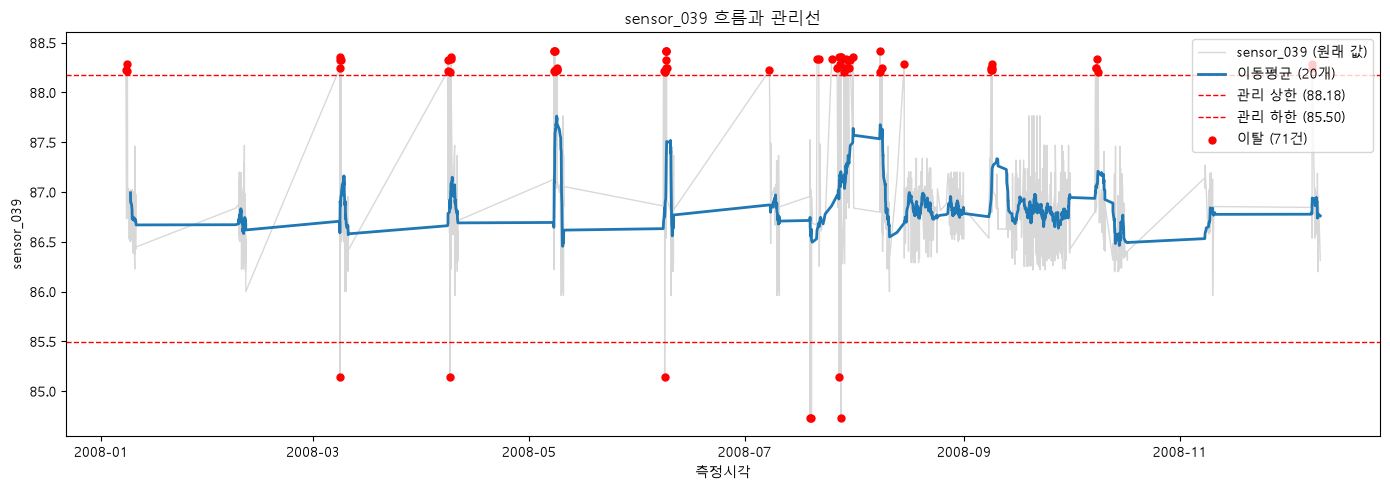

저장 완료: results/sensor_trend.png


In [5]:
import os
import matplotlib.pyplot as plt

# 한글이 깨지지 않게
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

os.makedirs("results", exist_ok=True)

fig, ax = plt.subplots(figsize=(14, 5))

# 원래 값 - 옅게
ax.plot(df["측정시각"], df[센서], color="gray", alpha=0.3, linewidth=1, label=f"{센서} (원래 값)")

# 이동평균 - 진하게
ax.plot(df["측정시각"], df["이동평균"], color="tab:blue", linewidth=2, label="이동평균 (20개)")

# 관리 상한 / 하한 - 가로선
ax.axhline(상한, color="red", linestyle="--", linewidth=1, label=f"관리 상한 ({상한:.2f})")
ax.axhline(하한, color="red", linestyle="--", linewidth=1, label=f"관리 하한 ({하한:.2f})")

# 이탈 지점 - 눈에 띄게
이탈행 = df[df["이탈"]]
ax.scatter(이탈행["측정시각"], 이탈행[센서], color="red", s=25, zorder=5, label=f"이탈 ({len(이탈행)}건)")

ax.set_title(f"{센서} 흐름과 관리선")
ax.set_xlabel("측정시각")
ax.set_ylabel(센서)
ax.legend(loc="upper right")
fig.tight_layout()

fig.savefig("results/sensor_trend.png", dpi=150)
plt.show()

print("저장 완료: results/sensor_trend.png")

## Step 6. 조기 경보 목록으로 합치기

In [6]:
# df["이상탐지"]와 df["이탈"] 두 열만 써서 걸린 근거를 적는다
def 근거매기기(row):
    if row["이상탐지"] and row["이탈"]:
        return "둘 다"
    elif row["이상탐지"]:
        return "이상탐지"
    elif row["이탈"]:
        return "관리선"
    return None

df["근거"] = df.apply(근거매기기, axis=1)

# 우선순위: 둘 다 -> 나머지. 같은 순위 안에서는 측정시각 순
조기경보 = df[df["근거"].notna()].copy()
우선순위 = {"둘 다": 0, "이상탐지": 1, "관리선": 1}
조기경보["우선순위"] = 조기경보["근거"].map(우선순위)
조기경보 = 조기경보.sort_values(["우선순위", "측정시각"], kind="mergesort").drop(columns="우선순위")

print("조기경보 목록 건수:", len(조기경보))
print(조기경보["근거"].value_counts())
print()
print(조기경보[["측정시각", "근거", "불량여부"]].head(10))

조기경보 목록 건수: 119
근거
이상탐지    48
관리선     40
둘 다     31
Name: count, dtype: int64

                   측정시각   근거  불량여부
5   2008-01-08 12:29:00  둘 다     0
149 2008-03-08 13:09:00  둘 다     0
152 2008-03-08 15:03:00  둘 다     0
201 2008-04-08 03:49:00  둘 다     0
210 2008-04-08 18:24:00  둘 다     0
213 2008-04-08 20:58:00  둘 다     1
216 2008-04-08 23:33:00  둘 다     0
254 2008-05-08 03:36:00  둘 다     0
264 2008-05-08 07:48:00  둘 다     0
325 2008-06-08 21:15:00  둘 다     0


In [7]:
# 네 가지 숫자 - df["이상탐지"], df["이탈"], df["불량여부"]만 쓴다
둘다 = df["이상탐지"] & df["이탈"]
하나라도 = df["이상탐지"] | df["이탈"]

둘다건수 = 둘다.sum()
둘다불량 = (둘다 & (df["불량여부"] == 1)).sum()
둘다비율 = 둘다불량 / 둘다건수 * 100

하나라도건수 = 하나라도.sum()
하나라도불량 = (하나라도 & (df["불량여부"] == 1)).sum()
하나라도비율 = 하나라도불량 / 하나라도건수 * 100

전체불량 = (df["불량여부"] == 1).sum()
못잡은불량 = 전체불량 - 하나라도불량
전체불량률 = (df["불량여부"] == 1).mean() * 100

print(f"{'구분':16} {'건수':>6} {'그중 불량':>8} {'지목 중 진짜':>10}")
print(f"{'둘 다':16} {둘다건수:>6} {둘다불량:>8} {round(둘다비율,1):>9}%")
print(f"{'둘 중 하나라도':16} {하나라도건수:>6} {하나라도불량:>8} {round(하나라도비율,1):>9}%")
print()
print("이 목록으로 못 잡은 불량:", 못잡은불량, "건")
print("전체 불량률:", round(전체불량률, 2), "%")

구분                   건수    그중 불량    지목 중 진짜
둘 다                  31        8      25.8%
둘 중 하나라도            119       19      16.0%

이 목록으로 못 잡은 불량: 85 건
전체 불량률: 6.64 %


## Step 6. 조기 경보 리포트

| 걸린 근거 | 건수 | 그중 불량 | 지목 중 진짜 |
|---|---|---|---|
| 둘 다 | [31] | [8] | [25.8%] |
| 둘 중 하나라도 | [119] | [19] | [16.0%] |
| (견줄 값) 전체 불량률 | 1567 | [104] | [6.64%] |

- 먼저 열어볼 것 : [둘 다 걸린 27건. 전체 불량률의 네 배 반이라 여기부터 본다]
- 무엇을 근거로 : [이상탐지 두 방법이 같이 짚었고, 관리선도 넘었다]
- 놓친 것 : [불량 104건 중 85건은 이 목록에 없다]
- 아직 못 미더운 점 : [관리선은 센서 하나만 봤다. 나머지 마흔아홉 개는 안 봤다]
- 다음에 해볼 것 : [센서를 더 골라 관리선을 긋고 겹치는지 본다]

---
## 직접 해보기 (도전) - 센서를 더 보면 달라지나

- 상황: 관리선을 센서 하나에만 그었다. 더 그으면 어떻게 될까
- 할 일: 센서를 여러 개 골라 관리선을 긋고, 몇 개나 넘었는지로 순위를 매긴다
- 결과물: 다섯 줄짜리 표 1개 + 한 줄 메모

## 1단 — 센서를 여러 개 보기

In [8]:
# 센서마다 이탈 건수를 세서 20~100건인 센서를 고른다
이탈건수표 = {}
for col in sensor_cols:
    평균 = df[col].mean()
    표준편차 = df[col].std()
    상한 = 평균 + 3 * 표준편차
    하한 = 평균 - 3 * 표준편차
    이탈건수표[col] = ((df[col] > 상한) | (df[col] < 하한)).sum()
이탈건수표 = pd.Series(이탈건수표)

후보 = 이탈건수표[(이탈건수표 >= 20) & (이탈건수표 <= 100)]
고른센서 = list(후보.index[:5])
print("이탈 20~100건인 후보 센서 수:", len(후보))
print("고른 센서 다섯 개:", 고른센서)

# 고른 센서마다 관리선을 긋고, 넘은 센서 개수를 경보수 열로 만든다
경보수 = pd.Series(0, index=df.index)
for col in 고른센서:
    평균 = df[col].mean()
    표준편차 = df[col].std()
    상한 = 평균 + 3 * 표준편차
    하한 = 평균 - 3 * 표준편차
    이탈 = (df[col] > 상한) | (df[col] < 하한)
    경보수 = 경보수 + 이탈.astype(int)

df["경보수"] = 경보수

def 구간(n):
    if n == 0:
        return "0"
    elif n == 1:
        return "1"
    elif n == 2:
        return "2"
    else:
        return "3 이상"

df["경보수_구간"] = df["경보수"].apply(구간)

표 = df.groupby("경보수_구간").agg(
    건수=("불량여부", "size"),
    불량건수=("불량여부", "sum"),
)
표["지목중진짜"] = (표["불량건수"] / 표["건수"] * 100).round(1)
표 = 표.reindex(["0", "1", "2", "3 이상"])
print()
print(표)

이탈 20~100건인 후보 센서 수: 18
고른 센서 다섯 개: ['sensor_511', 'sensor_432', 'sensor_431', 'sensor_022', 'sensor_211']

          건수  불량건수  지목중진짜
경보수_구간                   
0       1478    86    5.8
1         57    11   19.3
2          8     1   12.5
3 이상      24     6   25.0


### 결과 정리 (실행 결과 기준)

고른 센서 다섯 개: `sensor_511`, `sensor_432`, `sensor_431`, `sensor_022`, `sensor_211`

| 경보수 | 건수 | 그중 불량 | 지목 중 진짜(%) |
|---|---|---|---|
| 0 | 1478 | 86 | 5.8% |
| 1 | 57 | 11 | 19.3% |
| 2 | 8 | 1 | 12.5% |
| 3 이상 | 24 | 6 | 25.0% |

**알아낸 것**: 경보수가 늘수록 대체로 불량 적중률도 올라간다(0→1→3이상: 5.8%→19.3%→25.0%). 다만 2건 구간(12.5%)은 표본이 8건뿐이라 흔들림이 크다.

## 2단 이동평균이 관리선을 넘는 구간

In [9]:
# 이동평균 자체의 평균/표준편차로 2 표준편차 관리선을 다시 긋는다
이동평균평균 = df["이동평균"].mean()
이동평균표준편차 = df["이동평균"].std()
상한2 = 이동평균평균 + 2 * 이동평균표준편차
하한2 = 이동평균평균 - 2 * 이동평균표준편차

print(f"이동평균 평균 {이동평균평균:.4f} / 표준편차 {이동평균표준편차:.4f}")
print(f"관리 상한(2sd) {상한2:.4f} / 관리 하한(2sd) {하한2:.4f}")

df["이동평균이탈"] = ((df["이동평균"] > 상한2) | (df["이동평균"] < 하한2)).fillna(False)

# 연속으로 이어진 이탈만 하나의 구간으로 묶는다
df["구간번호"] = (df["이동평균이탈"] != df["이동평균이탈"].shift(fill_value=False)).cumsum()

구간목록 = []
for 번호, g in df[df["이동평균이탈"]].groupby("구간번호"):
    시작 = g["측정시각"].min()
    끝 = g["측정시각"].max()
    건수 = len(g)
    불량건수 = int(g["불량여부"].sum())
    불량률 = round(불량건수 / 건수 * 100, 2)
    구간목록.append((시작, 끝, 건수, 불량건수, 불량률))

print()
print("넘은 구간 수:", len(구간목록))
print(f"{'시작':20} {'끝':20} {'건수':>4} {'불량':>4} {'불량률':>8}")
for 시작, 끝, 건수, 불량건수, 불량률 in 구간목록:
    print(f"{str(시작):20} {str(끝):20} {건수:>4} {불량건수:>4} {불량률:>7}%")

이동평균 평균 86.8351 / 표준편차 0.1932
관리 상한(2sd) 87.2215 / 관리 하한(2sd) 86.4487

넘은 구간 수: 5
시작                   끝                      건수   불량      불량률
2008-05-08 07:12:00  2008-05-10 04:48:00    21    2    9.52%
2008-06-08 20:17:00  2008-06-10 04:26:00    15    2   13.33%
2008-07-29 15:49:00  2008-07-29 15:49:00     1    1   100.0%
2008-07-29 21:07:00  2008-08-09 04:21:00    27    5   18.52%
2008-09-08 23:34:00  2008-09-13 00:25:00    13    2   15.38%


### 넘은 구간 5개

| 시작 | 끝 | 건수 | 불량 | 불량률 |
|---|---|---|---|---|
| 2008-05-08 07:12 | 2008-05-10 04:48 | 21 | 2 | 9.52% |
| 2008-06-08 20:17 | 2008-06-10 04:26 | 15 | 2 | 13.33% |
| 2008-07-29 15:49 | 2008-07-29 15:49 | 1 | 1 | 100.0% |
| 2008-07-29 21:07 | 2008-08-09 04:21 | 27 | 5 | 18.52% |
| 2008-09-08 23:34 | 2008-09-13 00:25 | 13 | 2 | 15.38% |

7월 29일~8월 9일 구간이 27건 중 5건(18.52%)으로 가장 크고 오래 지속됐고, 8월 초 3번째 구간은 단일 시점에서 불량 1건이 그대로 잡혀 100%로 나타납니다(표본이 1건뿐이라 참고용).

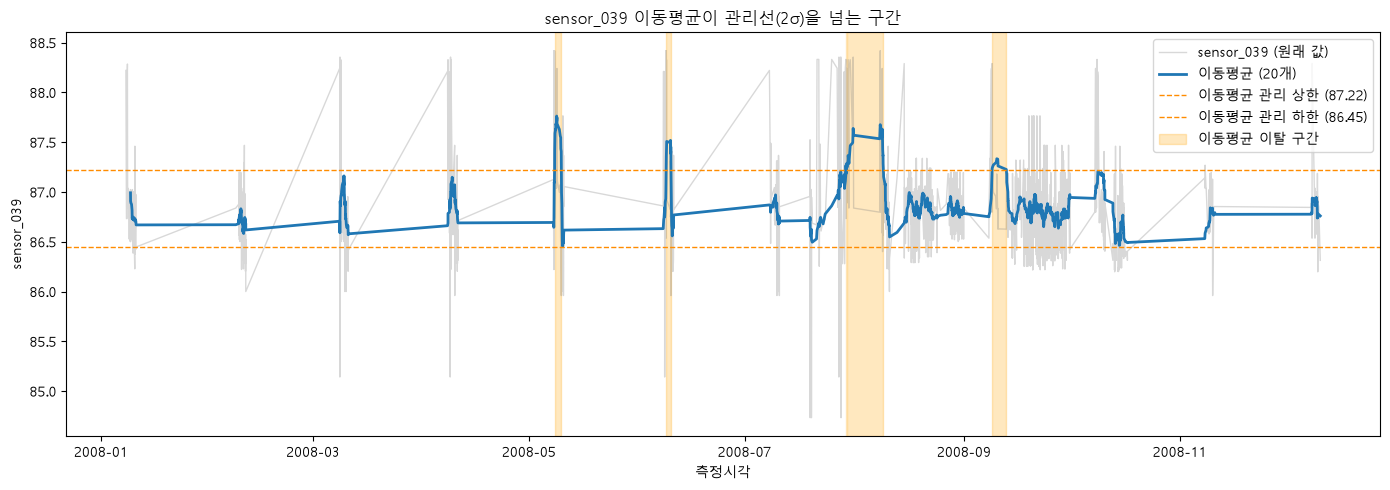

저장 완료: results/sensor_trend_zones.png


In [20]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["측정시각"], df[센서], color="gray", alpha=0.3, linewidth=1, label=f"{센서} (원래 값)")
ax.plot(df["측정시각"], df["이동평균"], color="tab:blue", linewidth=2, label="이동평균 (20개)")

ax.axhline(상한2, color="darkorange", linestyle="--", linewidth=1, label=f"이동평균 관리 상한 ({상한2:.2f})")
ax.axhline(하한2, color="darkorange", linestyle="--", linewidth=1, label=f"이동평균 관리 하한 ({하한2:.2f})")

# 넘은 구간을 색으로 표시
for i, (시작, 끝, 건수, 불량건수, 불량률) in enumerate(구간목록):
    ax.axvspan(시작, 끝, color="orange", alpha=0.25, label="이동평균 이탈 구간" if i == 0 else None)

ax.set_title(f"{센서} 이동평균이 관리선(2σ)을 넘는 구간")
ax.set_xlabel("측정시각")
ax.set_ylabel(센서)
ax.legend(loc="upper right")
fig.tight_layout()

fig.savefig("results/sensor_trend_zones.png", dpi=150)
plt.show()

print("저장 완료: results/sensor_trend_zones.png")

### 흐름이 선을 넘은 구간

| 구간 | 언제부터 언제까지 | 그 구간 건수 | 불량 | 불량률 |
|---|---|---|---|---|
| 1 | [5월 8일 ~ 5월 10일] | [21] | [2] | [9.52%] |
| 2 | [6월 8일 ~ 6월 10일] | [15] | [2] | [13.33%] |
| 3 | [7월 29일 한 줄] | [1] | [1] | [100.00%] |
| 4 | [7월 29일 ~ 8월 9일] | [27] | [5] | [18.52%] |
| 5 | [9월 8일 ~ 9월 13일] | [13] | [2] | [15.38%] |

- 알게 된 것 : [구간 안 77건의 불량률이 15.58%로 전체 6.64%의 두 배 넘는다. 4번 구간이 가장 길고 불량도 가장 많다]
- 이게 한 줄씩 보는 것과 다른 점 : [언제부터 언제까지인지 기간이 나온다. 그 날짜에 무슨 일이 있었는지 물어볼 수 있다]
- 못 믿을 줄 : [3번 구간은 1건짜리라 100%가 아무 뜻이 없다]